# Image Processing — "Performance Analysis"
**High Performance Computing · 7th Quarter · UPY**

This notebook benchmarks three image filters — **Gaussian**, **Sobel**, and **Median** — implemented in three different computational approaches: Pure Python, NumPy, and NumPy + Cython. The goal is to measure and compare execution times across implementations.

In [2]:
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from PIL import Image

from filters_pure_python import (
    gaussian_filter_pure, sobel_filter_pure, median_filter_pure,
    image_to_2d, list2d_to_image
)
from filters_numpy import (
    gaussian_filter_numpy, sobel_filter_numpy, median_filter_numpy
)
from filters_cython import (
    gaussian_filter_cython, sobel_filter_cython, median_filter_cython
)

print('All modules loaded successfully.')

All modules loaded successfully.


## 1 · Load Image
A grayscale test image is loaded or generated, and then converted into the formats required by each implementation:

Pure Python uses a two-dimensional list of integers.

NumPy / Cython use a np.ndarray with uint8 values.

Image loaded — size: (256, 256), height: 256, width: 256


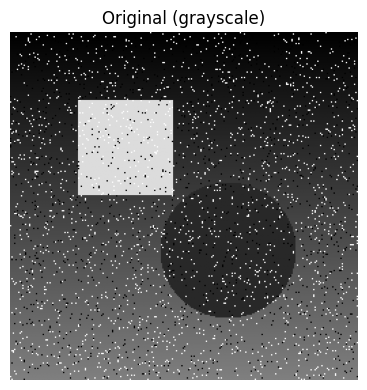

In [3]:
import os
import numpy as np
from PIL import Image

# ── Generate synthetic test image if none exists ──────────────────────────────
def make_test_image(path='sample.png', size=(256, 256)):
    rng = np.random.default_rng(42)
    arr = np.zeros(size, dtype=np.uint8)
    for i in range(size[0]):
        arr[i, :] = int(i / size[0] * 128)          # background gradient
    arr[50:120, 50:120] = 220                         # white rectangle
    cy, cx, r = 160, 160, 50                          # dark circle
    ys, xs = np.ogrid[:size[0], :size[1]]
    arr[(ys - cy)**2 + (xs - cx)**2 < r**2] = 40
    noise = rng.integers(0, 100, size=size)           # salt-and-pepper noise
    arr[noise < 3]  = 255
    arr[noise > 97] = 0
    Image.fromarray(arr, 'L').save(path)
    return path

INPUT_PATH = 'sample.png'
if not os.path.exists(INPUT_PATH):
    make_test_image(INPUT_PATH)

img      = Image.open(INPUT_PATH).convert('L')
arr      = np.array(img, dtype=np.uint8)          # for NumPy & Cython
pixels_2d, height, width = image_to_2d(img)       # for Pure Python

print(f'Image loaded — size: {img.size}, height: {height}, width: {width}')

plt.figure(figsize=(4, 4))
plt.imshow(arr, cmap='gray')
plt.title('Original (grayscale)')
plt.axis('off')
plt.tight_layout()
plt.show()

## 2 · Benchmark
Each filter is executed five times for every implementation.
The median execution time is used to minimize variations caused by the operating system or background processes.

In [4]:
N_RUNS = 5

def bench_numpy(func, arg, n=N_RUNS):
    """Benchmark a NumPy/Cython filter (takes ndarray, returns ndarray)."""
    times = []
    for _ in range(n):
        t0 = time.perf_counter()
        result = func(arg)
        times.append(time.perf_counter() - t0)
    return result, float(np.median(times))

def bench_pure(func, pixels, h, w, n=N_RUNS):
    """Benchmark a Pure Python filter (takes 2-D list + dims)."""
    times = []
    for _ in range(n):
        t0 = time.perf_counter()
        result = func(pixels, h, w)
        times.append(time.perf_counter() - t0)
    return result, float(np.median(times))

print(f'Running each filter {N_RUNS} times — recording median time...\n')

results = {}   # results[filter_name][approach] = output array/list
timings = {}   # timings[(filter_name, approach)] = seconds

schedule = [
    ('Gaussian', gaussian_filter_pure, gaussian_filter_numpy, gaussian_filter_cython),
    ('Sobel',    sobel_filter_pure,    sobel_filter_numpy,    sobel_filter_cython),
    ('Median',   median_filter_pure,   median_filter_numpy,   median_filter_cython),
]

for filter_name, fn_py, fn_np, fn_cy in schedule:
    results[filter_name] = {}

    res, t = bench_pure(fn_py, pixels_2d, height, width)
    results[filter_name]['Pure Python'] = np.array(res, dtype=np.uint8)
    timings[(filter_name, 'Pure Python')] = t
    print(f'{filter_name:<10} Pure Python    : {t:.4f} s')

    res, t = bench_numpy(fn_np, arr)
    results[filter_name]['NumPy'] = res
    timings[(filter_name, 'NumPy')] = t
    print(f'{filter_name:<10} NumPy          : {t:.4f} s')

    res, t = bench_numpy(fn_cy, arr)
    results[filter_name]['NumPy + Cython'] = res
    timings[(filter_name, 'NumPy + Cython')] = t
    print(f'{filter_name:<10} NumPy + Cython : {t:.4f} s')
    print()

Running each filter 5 times — recording median time...

Gaussian   Pure Python    : 0.0340 s
Gaussian   NumPy          : 0.0003 s
Gaussian   NumPy + Cython : 0.0003 s

Sobel      Pure Python    : 0.0549 s
Sobel      NumPy          : 0.0004 s
Sobel      NumPy + Cython : 0.0003 s

Median     Pure Python    : 0.0261 s
Median     NumPy          : 0.0013 s
Median     NumPy + Cython : 0.0010 s



## 3 · Results Table
A table shows execution times together with speedup ratios, indicating how much faster each implementation is compared to Pure Python, and also how Cython compares to NumPy.

In [5]:
filters    = ['Gaussian', 'Sobel', 'Median']
approaches = ['Pure Python', 'NumPy', 'NumPy + Cython']

data = {app: [timings[(f, app)] for f in filters] for app in approaches}
df = pd.DataFrame(data, index=filters)
df.index.name = 'Filter'

df['Speedup NumPy / Python']   = df['Pure Python'] / df['NumPy']
df['Speedup Cython / Python']  = df['Pure Python'] / df['NumPy + Cython']
df['Speedup Cython / NumPy']   = df['NumPy']        / df['NumPy + Cython']

time_cols  = approaches
speed_cols = [c for c in df.columns if 'Speedup' in c]

styled = (df.style
    .format({c: '{:.4f} s' for c in time_cols})
    .format({c: '{:.1f}x'  for c in speed_cols})
    .background_gradient(subset=time_cols,  cmap='RdYlGn_r')
    .background_gradient(subset=speed_cols, cmap='YlGn')
    .set_caption('Table 1 — Median execution time over 5 runs + speedup factors')
)
styled

,Pure Python,NumPy,NumPy + Cython,Speedup NumPy / Python,Speedup Cython / Python,Speedup Cython / NumPy
Filter,,,,,,
Gaussian,0.034037,0.000309,0.000297,110.0x,114.8x,1.0x
Sobel,0.054939,0.000395,0.000260,139.2x,210.9x,1.5x
Median,0.026082,0.001302,0.000995,20.0x,26.2x,1.3x


## 4 · Bar Charts
Two bar charts display the same results:

- A linear scale to highlight the overall performance difference

- A logarithmic scale to make the difference between NumPy and Cython easier to see

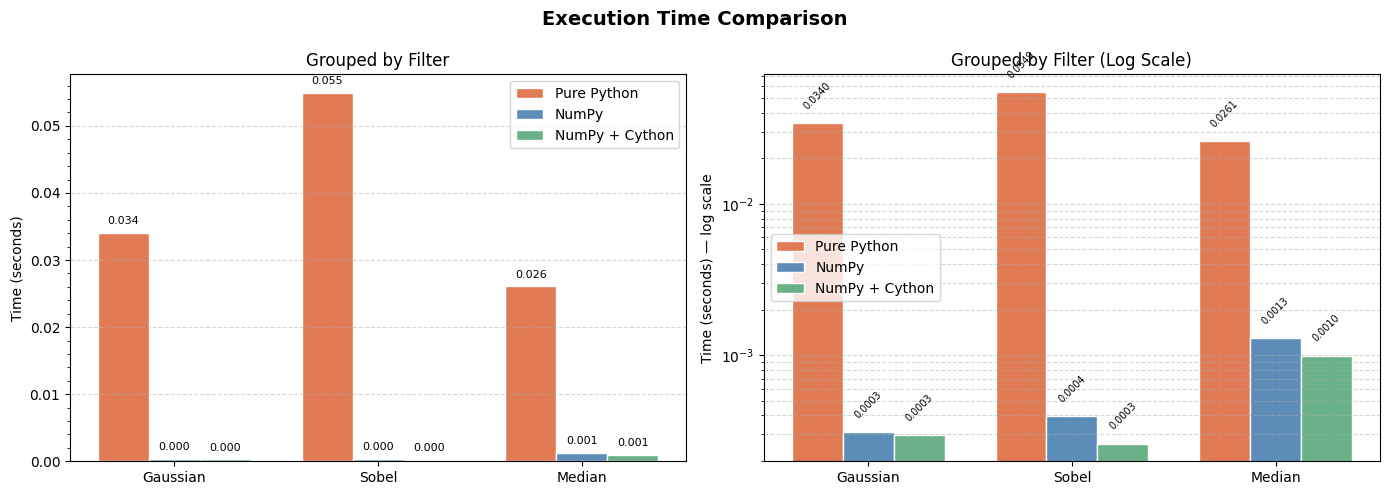

In [6]:
colors = {'Pure Python': '#e07b54', 'NumPy': '#5b8db8', 'NumPy + Cython': '#6ab187'}
x     = np.arange(len(filters))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Execution Time Comparison', fontsize=14, fontweight='bold')

# ── Left: linear scale ────────────────────────────────────────────────────────
ax = axes[0]
for i, approach in enumerate(approaches):
    vals = [timings[(f, approach)] for f in filters]
    bars = ax.bar(x + i * width, vals, width, label=approach,
                  color=colors[approach], edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(filters)
ax.set_ylabel('Time (seconds)')
ax.set_title('Grouped by Filter')
ax.legend()
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(axis='y', linestyle='--', alpha=0.5)

# ── Right: log scale ──────────────────────────────────────────────────────────
ax2 = axes[1]
for i, approach in enumerate(approaches):
    vals = [timings[(f, approach)] for f in filters]
    bars = ax2.bar(x + i * width, vals, width, label=approach,
                   color=colors[approach], edgecolor='white')
    for bar, v in zip(bars, vals):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.2,
                 f'{v:.4f}', ha='center', va='bottom', fontsize=7, rotation=45)

ax2.set_xticks(x + width)
ax2.set_xticklabels(filters)
ax2.set_ylabel('Time (seconds) — log scale')
ax2.set_title('Grouped by Filter (Log Scale)')
ax2.set_yscale('log')
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.5, which='both')

plt.tight_layout()
plt.savefig('benchmark_bar_chart.png', dpi=150)
plt.show()

## 5 · Speedup Heatmap
The heatmap indicates how many times faster one method is compared to another.
A darker green color means a greater performance improvement.

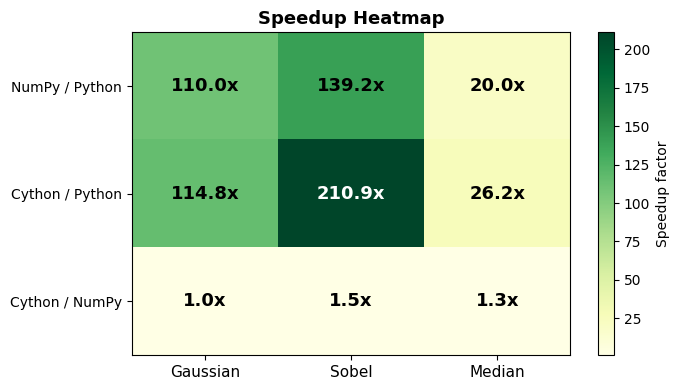

In [7]:
speedup_labels = ['NumPy / Python', 'Cython / Python', 'Cython / NumPy']
speedup_data   = np.array([
    [timings[(f, 'Pure Python')] / timings[(f, 'NumPy')]          for f in filters],
    [timings[(f, 'Pure Python')] / timings[(f, 'NumPy + Cython')] for f in filters],
    [timings[(f, 'NumPy')]       / timings[(f, 'NumPy + Cython')] for f in filters],
])

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(speedup_data, cmap='YlGn', aspect='auto')

ax.set_xticks(range(len(filters)))
ax.set_xticklabels(filters, fontsize=11)
ax.set_yticks(range(len(speedup_labels)))
ax.set_yticklabels(speedup_labels, fontsize=10)

for i in range(len(speedup_labels)):
    for j in range(len(filters)):
        val   = speedup_data[i, j]
        color = 'black' if val < speedup_data.max() * 0.75 else 'white'
        ax.text(j, i, f'{val:.1f}x', ha='center', va='center',
                fontsize=13, fontweight='bold', color=color)

plt.colorbar(im, ax=ax, label='Speedup factor')
ax.set_title('Speedup Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('benchmark_heatmap.png', dpi=150)
plt.show()

## 6 · Visual Results
The original image is shown next to the filtered versions.
Each title also includes the median execution time measured during the benchmark.

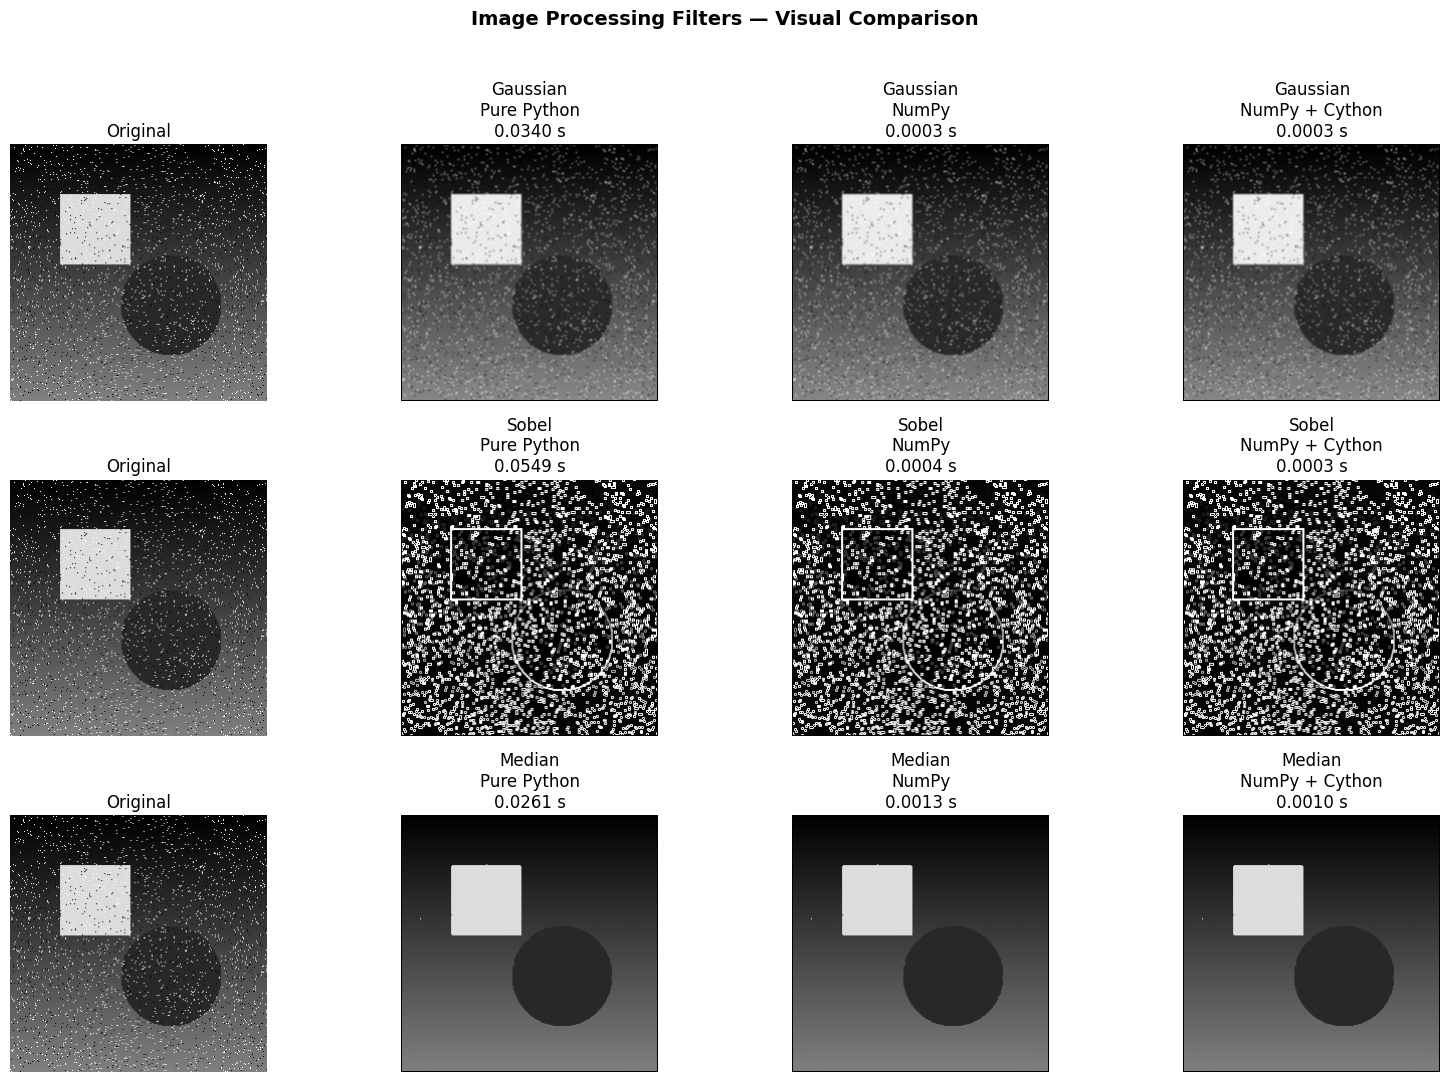

In [8]:
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
fig.suptitle('Image Processing Filters — Visual Comparison', fontsize=14, fontweight='bold')

plot_layout = [
    ('Gaussian', results['Gaussian']['Pure Python'], results['Gaussian']['NumPy'], results['Gaussian']['NumPy + Cython']),
    ('Sobel',    results['Sobel']['Pure Python'],    results['Sobel']['NumPy'],    results['Sobel']['NumPy + Cython']),
    ('Median',   results['Median']['Pure Python'],   results['Median']['NumPy'],   results['Median']['NumPy + Cython']),
]

for row, (fname, res_py, res_np, res_cy) in enumerate(plot_layout):
    t_py = timings[(fname, 'Pure Python')]
    t_np = timings[(fname, 'NumPy')]
    t_cy = timings[(fname, 'NumPy + Cython')]

    axes[row, 0].imshow(arr,    cmap='gray'); axes[row, 0].set_title('Original');                                      axes[row, 0].axis('off')
    axes[row, 1].imshow(res_py, cmap='gray'); axes[row, 1].set_title(f'{fname}\nPure Python\n{t_py:.4f} s');        axes[row, 1].axis('off')
    axes[row, 2].imshow(res_np, cmap='gray'); axes[row, 2].set_title(f'{fname}\nNumPy\n{t_np:.4f} s');              axes[row, 2].axis('off')
    axes[row, 3].imshow(res_cy, cmap='gray'); axes[row, 3].set_title(f'{fname}\nNumPy + Cython\n{t_cy:.4f} s');    axes[row, 3].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('comparative_visualization.png', dpi=150)
plt.show()

## 7 · Pixel Intensity Histograms
These histograms show how each filter changes the distribution of pixel intensities.
The gray histogram represents the original image and is used as a reference.

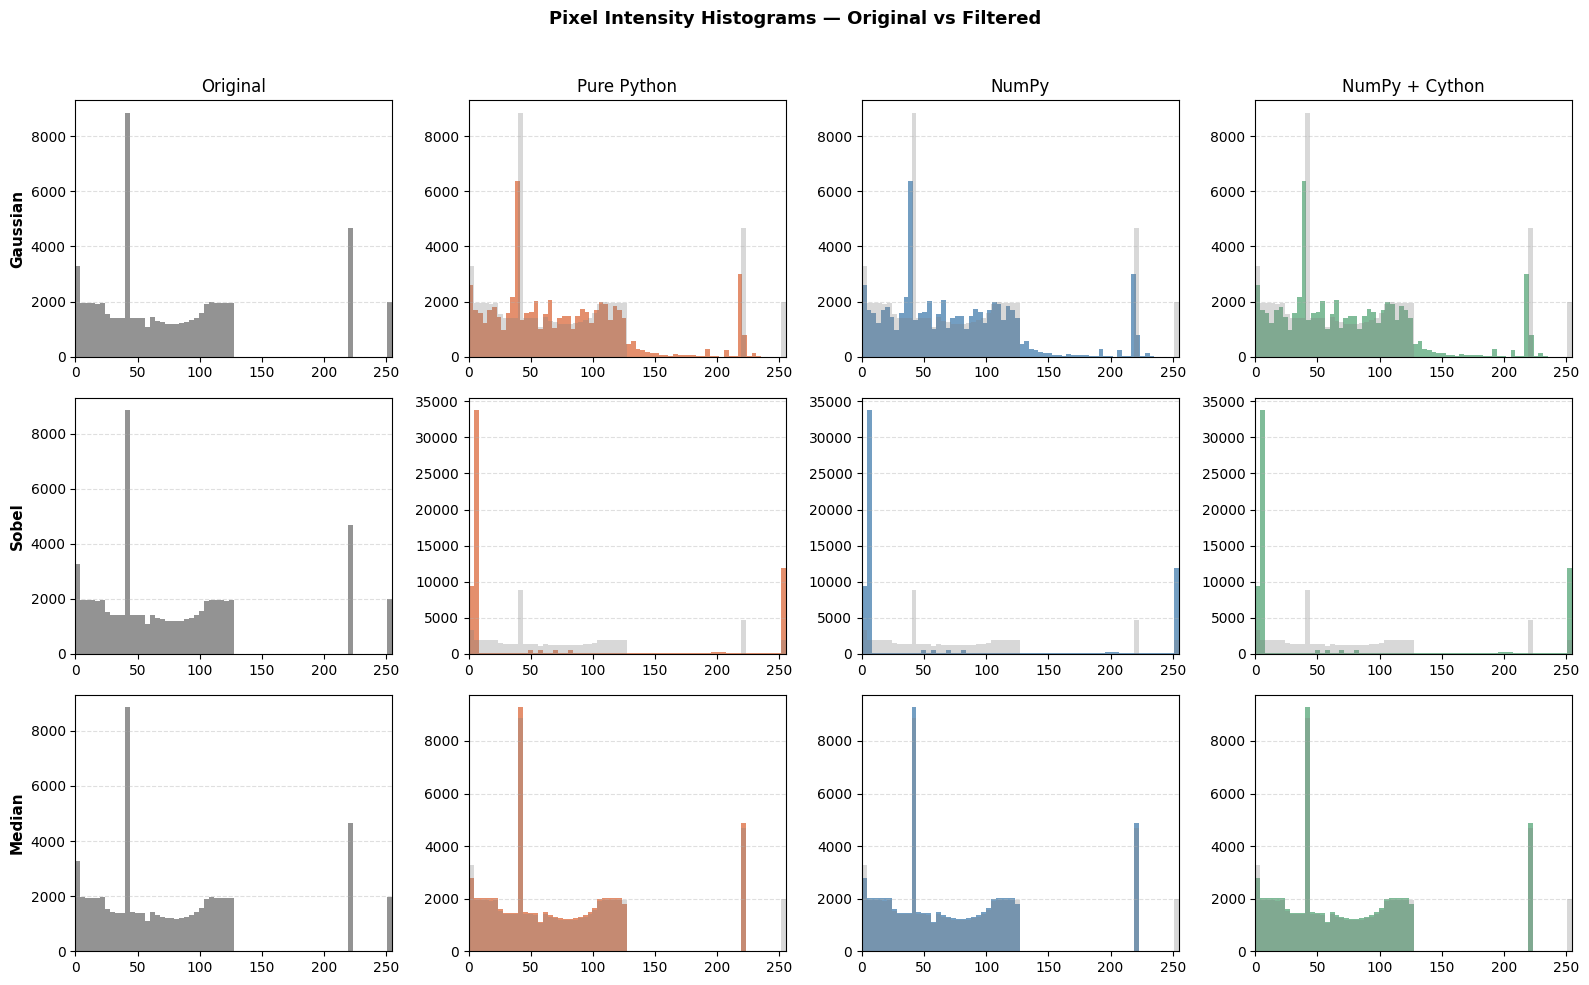

In [9]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle('Pixel Intensity Histograms — Original vs Filtered', fontsize=13, fontweight='bold')

bins          = 64
original_flat = arr.ravel()

for row, fname in enumerate(['Gaussian', 'Sobel', 'Median']):
    ax_orig = axes[row, 0]
    ax_orig.hist(original_flat, bins=bins, color='gray', edgecolor='none', alpha=0.85)
    ax_orig.set_title('Original' if row == 0 else '')
    ax_orig.set_ylabel(fname, fontsize=11, fontweight='bold')
    ax_orig.set_xlim(0, 255)
    ax_orig.grid(axis='y', linestyle='--', alpha=0.4)

    for col, (approach_key, color, label) in enumerate([
        ('Pure Python',    colors['Pure Python'],   'Pure Python'),
        ('NumPy',          colors['NumPy'],          'NumPy'),
        ('NumPy + Cython', colors['NumPy + Cython'], 'NumPy + Cython'),
    ]):
        ax  = axes[row, col + 1]
        flat = results[fname][approach_key].ravel()
        ax.hist(flat,          bins=bins, color=color,  edgecolor='none', alpha=0.85)
        ax.hist(original_flat, bins=bins, color='gray', edgecolor='none', alpha=0.3)
        if row == 0:
            ax.set_title(label)
        ax.set_xlim(0, 255)
        ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('benchmark_histograms.png', dpi=150)
plt.show()

## 8 · Key Observations

### Performance behavior

- Pure Python is the slowest approach because every pixel is processed through Python’s interpreter loop, which introduces large overhead.

- NumPy is much faster since operations are executed using optimized C/BLAS routines, removing most loop overhead.

- NumPy + Cython gives the best performance for Gaussian and Sobel filters because contiguous typed arrays and pre-allocated buffers behave similarly to compiled Cython memoryviews.

### Why Cython is not always faster for Median

The Median filter behaves differently.
np.median internally uses an introselect algorithm, which is a highly optimized C implementation of partial sorting.
The Cython-style version sorts all elements using .sort() for each pixel, which may not be faster than NumPy’s optimized routine.
Cython is most beneficial when the main limitation is Python loop overhead, not when NumPy already provides a highly optimized function.

### Trade-off summary

| Approach | Ease of implementation | Speed |
|---|---|---|
| Pure Python | Very simple, only loops | Slowest (baseline) |
| NumPy | Simple and concise array operations| ~10–120× faster |
| NumPy + Cython | Medium complexity, typed arrays required | ~15–150× faster |